# Tugas 4

https://www.tensorflow.org/datasets/catalog/mnist

The MNIST database of handwritten digits (0 sampai 9).
train: 60.000
test: 10.000
fitur: image (shape 28, 28, 1 --> 28*28 pixel), label

struktur data
X_train: array gambar --> shape (60000, 28, 28)
y_train: label angka --> shape (60000,)
sama untuk test set

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# ambil dataset MNIST. otomatis download kalau belum ada
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Flatten images: 28x28 → 784
X_train_flat = X_train.reshape(-1, 28*28) / 255.0

I0000 00:00:1774876916.064651    4714 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774876917.009536    4714 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774876919.224079    4714 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


flatten images
shape awal (60000, 28, 28). setelah reshape menjadi (60000, 784) --> tiap gambar jadi vektor 784 dimensi

kenapa harus diflatten? karena PCA bekerja pada matriks 2D (tabel), yaitu data berbentuk X = (n_samples, n_features) --> 60000 images (sample), 784 pixel (fitur)
kenapa PCA hanya bisa bekerja pada matriks 2D? karena PCA ngertinya vektor angka. selain itu, covariance bisa dihitung jika datanya berupa tabel | sampel | fitur1 | fitur2 | ... |

shape (60000, 28, 28) --> 3D --> maksudnya ada 60000 matriks, masing2 matriks berukuran 28x28 --> data masih berbentuk gambar
shape (60000, 784) --> 2D --> 60000 baris, 784 kolom

`-1` --> biarin numpy menentukan jumlah baris otomatis
aturan reshape: jumlah total elemen ga boleh berubah
60000 × 28 × 28 = 47.040.000
kalau pakai `-1`, artinya kolom 784 (ditentukan oleh kita) dan barisnya dihitung oleh numpy secara otomatis (47.040.000 / 784 = 60000)
selain itu, biar lebih fleksiberl kalau jumlah samplenya berubah.



`/ 255.0` --> ini untuk normalisasi pixel 
kenapa dibagi 255? karena pixel grayscale = 0-255

range awal [0,255]
range setelah normalisasi [0,1]

0 --> 0
255 --> 1

In [2]:
np.random.seed(0) #set random seed (pseudo-random)

# tambah noise
noise_factor = 0.5 
X_train_noisy = X_train_flat + noise_factor * np.random.randn(*X_train_flat.shape)
# clipping
X_train_noisy = np.clip(X_train_noisy, 0., 1.)  # keep values between 0-1

set random seed biar hasil random konsisten. tanpa random seed, noise beda-beda.
kenapa 0? sebenernya bebas. berapapun valid

tambah noise
X_noisy = X + α * noise  --> additive noise model (ANM) 
X = `X_train_flat`
α (intensitas noise, untuk mengatur seberapa kuat noise) = `noise_factor`
0.1 → noise kecil
0.5 → sedang
1.0 → besar
2.0 → sangat rusak

noise = `np.random.randn(*X_train_flat.shape)` = ~ N(0,1) (Gaussian)
`np.random.randn(*shape)` --> artinya generate random dari distribusi normal (gaussian) N(0,1) --> agar noise rata-rata 0 (tidak bias)

clipping (memmbatasi nilai ke dalam rentang tertentu) `np.clip(data, min, max)`
setelah tambah noise, bisa <0 dan bisa >1. padahal, pixel [0,1] --> 0 = hitam, 1 = putih, di antaranya = abu-abu
jadi, clipping memaksa data tetap berada dalam batas yang valid

`np.clip(X, 0., 1.)` --> artinya:
kalau < 0 → jadi 0
kalau > 1 → jadi 1


In [4]:
# PCA

## 1. standardisasi data
X_mean = X_train_noisy.mean(axis=0)
X_std = X_train_noisy.std(axis=0)
X_train_std = (X_train_noisy - X_mean) / X_std

# 2. hitung ovariance matrix
cov_matrix = np.cov(X_train_std, rowvar=False)

# 3. eigen decomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print(eigenvalues.shape, eigenvectors.shape)

# 4. sort eigenvectors by eigenvalues descending
idx = np.argsort(eigenvalues)[::-1]
eigenvectors = eigenvectors[:, idx]
eigenvalues = eigenvalues[idx]

n_components = 50
top_vectors = eigenvectors[:, :n_components]  # shape (784,50)

# 5. project data (proyeksi ke ruang berdimensi rendah)
X_train_pca = X_train_std @ top_vectors  # shape (num_samples, 50)

# 6. reconstruct images from PCA (rekonstruksi dari 50 ke ruang asli 784)
X_train_reconstructed_std = X_train_pca @ top_vectors.T  # (num_samples,784)
# kembali ke skala asli (inverse dari standardisasi)
X_train_reconstructed = X_train_reconstructed_std * X_std + X_mean 
# clipping lagi
X_train_reconstructed = np.clip(X_train_reconstructed, 0., 1.)

(784,) (784, 784)


tahap 1
`axis=0` --> hitung per kolom (per pixel)
standardisasi (mean 0, std 1) agar fitur dengan variansi besar tidak mendominasi


tahap 2
bentuk matriksnya 784x784

kenapa 'rowvar=False'?
default numpy `rowvar=True` --> baris = fitur, kolom sampel --> jadi shape yg diharapkan numpy adalah (784, 60000)
tanpa rowvar=False --> matriksnya akan menjadi 60000x60000


tahap 3
eigenvalues → besar variansi
eigenvectors → arah (basis baru)
eigenvalues.shape = (784,)
eigenvectors.shape = (784, 784)

tahap 4
`[::-1]` --> besar ke kecil
`eigenvalues = eigenvalues[idx]` --> susun ulang eigenvalues sesuai urutan baru
`eigenvectors = eigenvectors[:, idx]` --> `:` ambil semua baris, `idx` pilih kolom sesuai urutan baru --> ambil semua eigenvector, tapi urutkan kolomnya sesuai urutan eigenvalue

tahap 5 --> ini bagian denoising
ambil komponen utama. komponen kecil (noise) dibuang.
reduksi 784 dimensi menjadi 50 dimensi

tahap 6
kenapa perlu clipping lagi setelah PCA? karena saat rekonstruksi hasilnya bisa <0 dan bisa >1. kenapa bisa keluar dari range? karena PCA itu kombinasi linear, tidak ada batasan nilai


`[:, :n_components]`
bentuk awal eigenvectors --> (784, 784)
`:` --> semua baris
`:50` --> ambil 50 kolom pertama (tiap kolom = 1 eigenvector)
hasil --> (784, 50)



jadi:
awalnya (60000, 784)
PCA (60000, 50)
reconstruct (60000, 784)


eigenvalue = variance di arah eigenvector

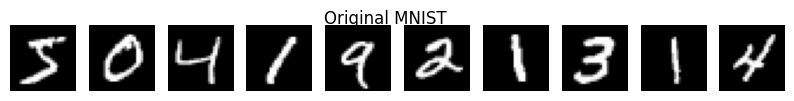

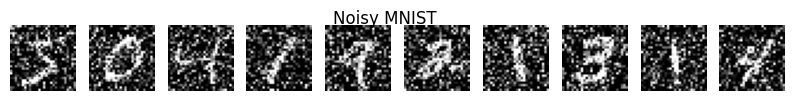

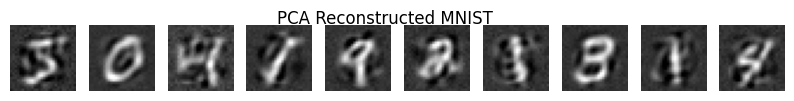

In [5]:
# Visualisasi

def plot_mnist_images(images, n=10, title=""):
    plt.figure(figsize=(n,1))
    for i in range(n):
        plt.subplot(1,n,i+1)
        plt.imshow(images[i].reshape(28,28), cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# Original
plot_mnist_images(X_train_flat, n=10, title="Original MNIST")

# Noisy
plot_mnist_images(X_train_noisy, n=10, title="Noisy MNIST")

# PCA Reconstructed
plot_mnist_images(X_train_reconstructed, n=10, title="PCA Reconstructed MNIST")